# 14_3. 행정동 유형화 최종 확정 — 수정사항 반영본

기존 `14_2`의 최종 서비스 구조는 유지하고, 이번 합의사항만 반영해 다시 작성한다.

## 유지하는 기존 구조
- 상위 설명 레이어: **4사분면**
- 세부 분류 레이어: **6개 Fuzzy C-Means 유형**
- 유형별 **대표동 / 경계동**
- 청년 1인세대 비율 **사후해석**
- PCA 설명용 시각화

## 이번에 수정하는 내용
1. **표면주거비**
   - 주택유형별 중앙값의 표본수 가중평균을 사용하지 않는다.
   - `표면주거비_거래단위.csv`의 유효 거래를 행정동별로 pooled하여 중앙값을 계산한다.
2. **생활소비부담지수**
   - 최종 유형화 변수에서 제외한다.
3. **청년 1인세대 비율**
   - 군집 변수에서 제외하고 사후해석에만 사용한다.
4. **표면주거비 결측**
   - KNN/유사동 방식으로 임의 대체하지 않는다.
   - 유형화 학습에서는 complete-case만 사용하고, 최종 427개 결과에는 `유형화_데이터부족=True`로 남긴다.
5. 기존 14번 비교 결과에서 확정한 최종 방식은 유지한다.
   - 부담 블록 50% + 통근구조 블록 50%
   - Fuzzy C-Means
   - k=6, m=1.5

즉, **유형화 방식 자체를 새로 바꾸는 노트북이 아니라 데이터 처리 기준만 수정한 최종 실행본**이다.

In [1]:
# =========================================================
# 1. 라이브러리 / 기본 설정
# =========================================================

from pathlib import Path
import re
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from scipy.stats import kruskal

try:
    import skfuzzy as fuzz
except ImportError as e:
    raise ImportError(
        "최종 유형화는 기존 14_2에서 선택된 Fuzzy C-Means를 사용합니다. "
        "현재 환경에 scikit-fuzzy가 없습니다. `pip install scikit-fuzzy` 후 다시 실행하세요."
    ) from e

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
EXPECTED_DONG_COUNT = 427

# 기존 14_2 최종 선택값
FINAL_K = 6
FUZZY_M = 1.5

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# =========================================================
# 2. 프로젝트 경로
# =========================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    REPO_DIR = CURRENT_DIR.parent
elif (CURRENT_DIR / "notebooks").exists():
    REPO_DIR = CURRENT_DIR
else:
    raise FileNotFoundError(
        "저장소 루트 또는 notebooks 폴더에서 실행하세요.\n"
        f"현재 위치: {CURRENT_DIR}"
    )

WORKSPACE_DIR = REPO_DIR.parent
DATA_DIR = WORKSPACE_DIR / "project_data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

MASTER_FILE = PROCESSED_DIR / "행정동_기준코드표.csv"
HOUSING_TRANSACTION_FILE = RAW_DIR / "표면주거비_거래단위.csv"
COMMUTE_FILE = PROCESSED_DIR / "commute_burden_by_home_dong.csv"
NETWORK_FILE = PROCESSED_DIR / "commute_dong_network_metrics.csv"
DESTINATION_FILE = PROCESSED_DIR / "commute_destination_concentration_by_home_dong.csv"

def find_file_by_name(filename, roots):
    for root in map(Path, roots):
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        found = [p for p in root.rglob(filename) if ".git" not in p.parts]
        if found:
            return sorted(found, key=lambda p: len(p.parts))[0]
    return None

YOUTH_FILE = find_file_by_name(
    "youth_single_household_share_2025.csv",
    [PROCESSED_DIR, DATA_DIR, WORKSPACE_DIR],
)
if YOUTH_FILE is None:
    YOUTH_FILE = find_file_by_name(
        "youth_single_household_share_2023_2025.csv",
        [PROCESSED_DIR, DATA_DIR, WORKSPACE_DIR],
    )

for label, path in {
    "기준코드표": MASTER_FILE,
    "표면주거비 거래단위": HOUSING_TRANSACTION_FILE,
    "통근부담": COMMUTE_FILE,
    "통근권": NETWORK_FILE,
    "목적지 집중도": DESTINATION_FILE,
    "청년 1인세대": YOUTH_FILE,
}.items():
    print(f"{label}: {path}")

기준코드표: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/행정동_기준코드표.csv
표면주거비 거래단위: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/raw/표면주거비_거래단위.csv
통근부담: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_burden_by_home_dong.csv
통근권: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_dong_network_metrics.csv
목적지 집중도: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_destination_concentration_by_home_dong.csv
청년 1인세대: /Users/janghwayeong/Desktop/부트캠프_프로젝트/Analysis-of-Youth-Savings-Capacity-Project/data/youth_single_household_share_2023_2025.csv


In [3]:
# =========================================================
# 3. 공통 함수
# =========================================================

def read_csv_clean(path):
    if path is None or not Path(path).exists():
        raise FileNotFoundError(f"파일을 찾지 못했습니다: {path}")
    df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    df.columns = (
        df.columns.astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df

def normalize_admin_code_value(value):
    if pd.isna(value):
        return pd.NA
    text = re.sub(r"\.0$", "", str(value).strip())
    digits = re.sub(r"\D", "", text)
    if len(digits) == 8:
        return digits + "00"
    if len(digits) == 10:
        if digits.startswith("00"):
            return digits[2:] + "00"
        return digits
    return pd.NA

def normalize_code(series):
    return series.map(normalize_admin_code_value).astype("string")

def find_col(df, candidates, label, required=True):
    col = next((c for c in candidates if c in df.columns), None)
    if col is None and required:
        raise KeyError(
            f"{label}에서 필요한 열을 찾지 못했습니다.\n"
            f"후보: {candidates}\n"
            f"현재 열: {df.columns.tolist()}"
        )
    return col

def numeric(series):
    return pd.to_numeric(series, errors="coerce")

def assert_unique(df, col, label):
    if df[col].duplicated().any():
        dup = df[df[col].duplicated(keep=False)].sort_values(col)
        display(dup.head(30))
        raise ValueError(f"{label}: {col} 중복이 있습니다.")

## 4. 427개 행정동 기준표

최종 결과는 427개 행정동 전체를 유지한다.  
단, 군집 생성에 필요한 지표가 결측인 동은 임의 대체하지 않고 유형을 비워 둔다.

In [4]:
master_raw = read_csv_clean(MASTER_FILE)

code_col = find_col(master_raw, ["행정동코드10", "행정동코드_최종", "행정기관코드"], "기준코드표")
name_col = find_col(master_raw, ["행정동명", "행정동명_최종", "행정동"], "기준코드표")
gu_col = find_col(master_raw, ["시군구명", "자치구", "자치구명"], "기준코드표")
region_col = find_col(master_raw, ["권역"], "기준코드표", required=False)

cols = [code_col, gu_col, name_col] + ([region_col] if region_col else [])
master = master_raw[cols].copy()
master = master.rename(columns={
    code_col: "행정동코드",
    gu_col: "시군구명",
    name_col: "행정동명",
    **({region_col: "권역"} if region_col else {}),
})
master["행정동코드"] = normalize_code(master["행정동코드"])

assert_unique(master, "행정동코드", "기준코드표")
assert len(master) == EXPECTED_DONG_COUNT
print("기준 행정동 수:", len(master))
display(master.head())

기준 행정동 수: 427


,행정동코드,시군구명,행정동명,권역
0,1111051500,종로구,청운효자동,도심권
1,1111053000,종로구,사직동,도심권
2,1111054000,종로구,삼청동,도심권
3,1111055000,종로구,부암동,도심권
4,1111056000,종로구,평창동,도심권


## 5. 표면주거비 — 거래단위 pooled 중앙값

`표면주거비_거래단위.csv`에서 **각 거래 행의 표면주거비**를 가져와  
행정동별 모든 유효 거래를 한데 모은 뒤 중앙값을 계산한다.

- 주택유형별 중앙값 → 가중평균 방식 **사용하지 않음**
- 결측 행정동의 값 **대체하지 않음**
- 거래 수는 품질 확인용으로 함께 저장

In [5]:
housing_raw = read_csv_clean(HOUSING_TRANSACTION_FILE)

housing_code_col = find_col(
    housing_raw,
    ["행정동코드_최종", "행정동코드10", "행정기관코드", "행정동코드"],
    "표면주거비 거래단위",
)

# 현재 거래단위 원자료의 실제 컬럼명을 그대로 사용한다.
# 확인된 원자료 컬럼:
# - 행정동코드_최종
# - 표면_주거비  (만원 단위)
housing_value_col = find_col(
    housing_raw,
    ["표면_주거비"],
    "표면주거비 거래단위",
)

housing_tx = housing_raw[[housing_code_col, housing_value_col]].copy()
housing_tx.columns = ["행정동코드", "표면주거비_만원"]

housing_tx["행정동코드"] = normalize_code(housing_tx["행정동코드"])
housing_tx["표면주거비_만원"] = numeric(housing_tx["표면주거비_만원"])

# `표면_주거비`는 만원 단위이므로 원 단위로 변환
housing_tx["표면주거비_원"] = housing_tx["표면주거비_만원"] * 10_000

housing_tx = housing_tx.dropna(
    subset=["행정동코드", "표면주거비_원"]
)
housing_tx = housing_tx[
    housing_tx["표면주거비_원"] > 0
].copy()

# 행정동별 모든 유효 거래를 pooled한 뒤 중앙값 계산
housing = (
    housing_tx
    .groupby("행정동코드", as_index=False)
    .agg(
        표면주거비_원=("표면주거비_원", "median"),
        표면주거비_거래수=("표면주거비_원", "size"),
    )
)

housing["표면주거비_집계방식"] = "거래단위 pooled 중앙값"

assert_unique(
    housing,
    "행정동코드",
    "행정동별 표면주거비",
)

print("원자료 행 수:", f"{len(housing_raw):,}")
print("표면주거비 유효 거래 수:", f"{len(housing_tx):,}")
print("표면주거비 산출 행정동 수:", len(housing))
print("기준표 대비 결측 예상 동 수:", EXPECTED_DONG_COUNT - len(housing))

display(
    housing
    .sort_values("표면주거비_거래수")
    .head(20)
)

원자료 행 수: 577,761
표면주거비 유효 거래 수: 577,745
표면주거비 산출 행정동 수: 420
기준표 대비 결측 예상 동 수: 7


,행정동코드,표면주거비_원,표면주거비_거래수,표면주거비_집계방식
41,1117063000,"1,127,500.0000",1,거래단위 pooled 중앙값
418,1174069000,"545,000.0000",3,거래단위 pooled 중앙값
400,1171071000,"1,271,875.0000",9,거래단위 pooled 중앙값
390,1171063100,"832,500.0000",11,거래단위 pooled 중앙값
157,1132071000,"680,983.3333",14,거래단위 pooled 중앙값
135,1130557500,"539,583.3333",14,거래단위 pooled 중앙값
160,1135058000,"480,833.3333",15,거래단위 pooled 중앙값
397,1171067000,"681,666.6667",16,거래단위 pooled 중앙값
5,1111057000,"562,500.0000",21,거래단위 pooled 중앙값
344,1165058000,"745,500.0000",22,거래단위 pooled 중앙값


## 6. 통근·통근구조 지표 불러오기

최종 군집 변수는 아래 5개만 사용한다.

- 표면주거비
- 대표 편도 통근시간
- 월 통근교통비
- 동일 통근권 내부 출근 비율
- 목적지 정규화 엔트로피

`목적지_HHI`는 교차 확인/프로파일용으로만 남기고,  
`청년1인세대_비율`은 사후해석용으로만 남긴다.

In [6]:
# 통근부담
commute_raw = read_csv_clean(COMMUTE_FILE)
c_code = find_col(commute_raw, ["거주동 코드", "거주_행정동_코드", "행정동코드10"], "통근부담")
c_time = find_col(commute_raw, ["대표_편도통근시간_분", "대표 편도 통근시간"], "통근부담")
c_cost = find_col(commute_raw, ["월_통근교통비_원", "월교통비_실지출_원", "월 통근 교통비"], "통근부담")

commute = commute_raw[[c_code, c_time, c_cost]].copy()
commute.columns = ["행정동코드", "대표_편도통근시간_분", "월통근교통비_원"]
commute["행정동코드"] = normalize_code(commute["행정동코드"])
for c in ["대표_편도통근시간_분", "월통근교통비_원"]:
    commute[c] = numeric(commute[c])
assert_unique(commute, "행정동코드", "통근부담")

# 통근권
network_raw = read_csv_clean(NETWORK_FILE)
n_code = find_col(network_raw, ["거주동 코드", "행정동 코드", "행정동코드10"], "통근권")
n_share = find_col(network_raw, ["동일통근권_내부출근비율", "동일_통근권_내부출근비율", "통근권_내부출근비율"], "통근권")

network = network_raw[[n_code, n_share]].copy()
network.columns = ["행정동코드", "동일통근권_내부출근비율"]
network["행정동코드"] = normalize_code(network["행정동코드"])
network["동일통근권_내부출근비율"] = numeric(network["동일통근권_내부출근비율"])
assert_unique(network, "행정동코드", "통근권")

# 목적지 집중도
dest_raw = read_csv_clean(DESTINATION_FILE)
d_code = find_col(dest_raw, ["거주동 코드", "행정동코드10", "행정동 코드"], "목적지")
d_hhi = find_col(dest_raw, ["목적지_HHI", "목적지 집중도"], "목적지")
d_ent = find_col(dest_raw, ["목적지_정규화엔트로피", "목적지 정규화 엔트로피"], "목적지")

destination = dest_raw[[d_code, d_hhi, d_ent]].copy()
destination.columns = ["행정동코드", "목적지_HHI", "목적지_정규화엔트로피"]
destination["행정동코드"] = normalize_code(destination["행정동코드"])
destination["목적지_HHI"] = numeric(destination["목적지_HHI"])
destination["목적지_정규화엔트로피"] = numeric(destination["목적지_정규화엔트로피"])
assert_unique(destination, "행정동코드", "목적지")

In [7]:
# 청년 1인세대 비율: 사후해석 전용
youth = pd.DataFrame(columns=["행정동코드", "청년1인세대_비율"])

if YOUTH_FILE is not None and Path(YOUTH_FILE).exists():
    youth_raw = read_csv_clean(YOUTH_FILE)
    y_code = find_col(youth_raw, ["행정기관코드", "행정동코드10", "행정동코드", "행정동코드_최종"], "청년 1인세대")
    y_share = find_col(
        youth_raw,
        ["청년1인세대비중", "청년1인세대_비율", "전체세대대비_청년1인세대비율", "전체세대대비_청년1인세대비율_3개년"],
        "청년 1인세대",
    )
    youth = youth_raw[[y_code, y_share]].copy()
    youth.columns = ["행정동코드", "청년1인세대_비율"]
    youth["행정동코드"] = normalize_code(youth["행정동코드"])
    youth["청년1인세대_비율"] = numeric(youth["청년1인세대_비율"])
    youth = youth.drop_duplicates("행정동코드")
else:
    print("청년 1인세대 파일이 없어 사후해석은 건너뜁니다.")

## 7. 427개 기준 결합 및 결측 플래그

결측은 채우지 않는다.  
군집 변수 5개 중 하나라도 결측이면 `유형화_데이터부족=True`로 처리한다.

In [8]:
analysis = (
    master
    .merge(housing, on="행정동코드", how="left", validate="one_to_one")
    .merge(commute, on="행정동코드", how="left", validate="one_to_one")
    .merge(network, on="행정동코드", how="left", validate="one_to_one")
    .merge(destination, on="행정동코드", how="left", validate="one_to_one")
    .merge(youth, on="행정동코드", how="left", validate="one_to_one")
)

CLUSTER_FEATURES = [
    "표면주거비_원",
    "대표_편도통근시간_분",
    "월통근교통비_원",
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
]

PROFILE_ONLY_FEATURES = ["목적지_HHI", "청년1인세대_비율"]

analysis["표면주거비_결측"] = analysis["표면주거비_원"].isna()
analysis["유형화_결측수"] = analysis[CLUSTER_FEATURES].isna().sum(axis=1)
analysis["유형화_결측목록"] = analysis.apply(
    lambda r: ", ".join([c for c in CLUSTER_FEATURES if pd.isna(r[c])]),
    axis=1,
)
analysis["유형화_데이터부족"] = analysis["유형화_결측수"] > 0

print("전체 행정동:", len(analysis))
print("유형화 가능:", (~analysis["유형화_데이터부족"]).sum())
print("유형화 데이터 부족:", analysis["유형화_데이터부족"].sum())
print("표면주거비 결측:", analysis["표면주거비_결측"].sum())

display(
    analysis.loc[
        analysis["유형화_데이터부족"],
        ["행정동코드", "시군구명", "행정동명", "유형화_결측수", "유형화_결측목록"]
    ]
)

전체 행정동: 427
유형화 가능: 420
유형화 데이터 부족: 7
표면주거비 결측: 7


,행정동코드,시군구명,행정동명,유형화_결측수,유형화_결측목록
164,1135061200,노원구,하계2동,1,표면주거비_원
174,1135070000,노원구,상계8동,1,표면주거비_원
175,1135071000,노원구,상계9동,1,표면주거비_원
346,1165055000,서초구,반포본동,1,표면주거비_원
348,1165057000,서초구,반포2동,1,표면주거비_원
389,1171056600,송파구,오륜동,1,표면주거비_원
407,1171072000,송파구,잠실7동,1,표면주거비_원


## 8. 최종 입력 표현 — 부담 50% + 구조 50%

기존 14_2 최종 선택 구조를 유지한다.

- 부담 블록: 표면주거비 / 통근시간 / 교통비
- 구조 블록: 동일 통근권 내부 출근 비율 / 목적지 엔트로피

각 변수는 먼저 표준화하고, 블록 전체의 제곱가중치 합이 0.5씩 되도록 조정한다.

In [9]:
eligible = analysis.loc[~analysis["유형화_데이터부족"]].copy().reset_index(drop=False)
eligible = eligible.rename(columns={"index": "원본행인덱스"})

BURDEN_FEATURES = [
    "표면주거비_원",
    "대표_편도통근시간_분",
    "월통근교통비_원",
]
STRUCTURE_FEATURES = [
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
]

burden_scaler = StandardScaler()
structure_scaler = StandardScaler()

burden_z = burden_scaler.fit_transform(eligible[BURDEN_FEATURES])
structure_z = structure_scaler.fit_transform(eligible[STRUCTURE_FEATURES])

burden_weight = np.sqrt(0.5 / len(BURDEN_FEATURES))
structure_weight = np.sqrt(0.5 / len(STRUCTURE_FEATURES))

X = np.column_stack([
    burden_z * burden_weight,
    structure_z * structure_weight,
])

print("유형화 입력 shape:", X.shape)

유형화 입력 shape: (420, 5)


## 9. Fuzzy C-Means 최종 6유형

기존 14_2에서 최종 선정된 `Fuzzy C-Means, k=6, m=1.5`를 그대로 사용한다.  
다만 이번에는 표면주거비 결측동을 제외한 complete-case 데이터만 학습한다.

In [10]:
centers, membership, _, _, _, _, fpc = fuzz.cluster.cmeans(
    X.T,
    c=FINAL_K,
    m=FUZZY_M,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=RANDOM_STATE,
)

labels0 = np.argmax(membership, axis=0)
max_membership = np.max(membership, axis=0)

eligible["군집_원번호"] = labels0 + 1
eligible["최대소속확률"] = max_membership
eligible["군집경계_모호"] = eligible["최대소속확률"] < 0.60

print("FPC:", round(float(fpc), 4))
print("평균 최대소속확률:", round(float(max_membership.mean()), 4))
print("소속확률 0.6 미만 비율:", round(float((max_membership < 0.60).mean()), 4))
print("Silhouette:", round(silhouette_score(X, labels0), 4))
print("Calinski-Harabasz:", round(calinski_harabasz_score(X, labels0), 4))
print("Davies-Bouldin:", round(davies_bouldin_score(X, labels0), 4))

display(
    eligible["군집_원번호"].value_counts().sort_index().rename("행정동수").to_frame()
)

FPC: 0.6003
평균 최대소속확률: 0.7184
소속확률 0.6 미만 비율: 0.3024
Silhouette: 0.2196
Calinski-Harabasz: 123.0058
Davies-Bouldin: 1.3184


,행정동수
군집_원번호,
1,51
2,72
3,66
4,85
5,115
6,31


## 10. 기존 최종 6개 유형명과 프로파일 매칭

Fuzzy C-Means의 군집 번호는 의미가 없고 실행마다 순서가 달라질 수 있다.  
따라서 기존 14_2에서 확정했던 6개 유형의 **5개 핵심 변수 Z-score 프로파일**을 기준 템플릿으로 두고,
새 군집 프로파일과 가장 가까운 유형명을 1:1 매칭한다.

이 방법은 **유형명 의미를 유지하면서도 새 pooled 주거비 데이터에 맞게 군집 자체는 다시 계산**하기 위한 장치다.

In [11]:
# 기존 14_2 최종 결과에서 확인한 핵심 5변수 Z-score 템플릿
# 순서: 표면주거비, 통근시간, 교통비, 동일통근권 내부출근비율, 목적지 엔트로피
ARCHETYPES = {
    "고비용 통근부담형":       [ 0.77,  0.15,  1.39,  0.76, -0.28],
    "근접통근 균형형":         [ 0.42, -0.81, -0.64,  0.17, -0.49],
    "광역분산 통근형":         [-0.18, -0.23, -0.33, -1.34,  0.50],
    "주거절감·장거리통근형":   [-0.71,  1.25,  0.17, -0.92,  1.07],
    "저주거비·지역연계형":     [-0.50,  0.38, -0.14,  0.65,  0.18],
    "고주거비·직주근접형":     [ 1.38, -1.74,  0.14,  1.05, -2.45],
}

# 새 데이터 전체 기준 Z-score
z_scaler = StandardScaler()
z_all = pd.DataFrame(
    z_scaler.fit_transform(eligible[CLUSTER_FEATURES]),
    columns=CLUSTER_FEATURES,
    index=eligible.index,
)

cluster_z = (
    z_all.assign(군집_원번호=eligible["군집_원번호"].values)
    .groupby("군집_원번호")[CLUSTER_FEATURES]
    .mean()
)

archetype_names = list(ARCHETYPES)
archetype_matrix = np.array([ARCHETYPES[n] for n in archetype_names], dtype=float)
cluster_matrix = cluster_z.values

distance_matrix = np.sqrt(
    ((cluster_matrix[:, None, :] - archetype_matrix[None, :, :]) ** 2).sum(axis=2)
)

row_idx, col_idx = linear_sum_assignment(distance_matrix)

cluster_to_type = {
    int(cluster_z.index[r]): archetype_names[c]
    for r, c in zip(row_idx, col_idx)
}

eligible["행정동_유형"] = eligible["군집_원번호"].map(cluster_to_type)

mapping_table = pd.DataFrame({
    "군집_원번호": list(cluster_to_type.keys()),
    "행정동_유형": list(cluster_to_type.values()),
})
mapping_table["템플릿거리"] = [
    distance_matrix[
        list(cluster_z.index).index(cluster_no),
        archetype_names.index(type_name)
    ]
    for cluster_no, type_name in zip(mapping_table["군집_원번호"], mapping_table["행정동_유형"])
]

display(mapping_table.sort_values("군집_원번호"))

,군집_원번호,행정동_유형,템플릿거리
0,1,고비용 통근부담형,0.0717
1,2,광역분산 통근형,0.0667
2,3,주거절감·장거리통근형,0.0577
3,4,근접통근 균형형,0.1517
4,5,저주거비·지역연계형,0.0783
5,6,고주거비·직주근접형,0.0599


## 11. 최종 프로파일 및 청년 1인세대 비율 사후해석

In [12]:
PROFILE_FEATURES = CLUSTER_FEATURES + [
    c for c in PROFILE_ONLY_FEATURES if c in eligible.columns
]

profile = (
    eligible.groupby(["군집_원번호", "행정동_유형"])
    .agg(
        행정동수=("행정동코드", "count"),
        **{
            f"{c}_평균": (c, "mean")
            for c in PROFILE_FEATURES
        }
    )
    .reset_index()
)

display(profile)

if "청년1인세대_비율" in eligible.columns and eligible["청년1인세대_비율"].notna().any():
    youth_profile = (
        eligible.groupby(["군집_원번호", "행정동_유형"])["청년1인세대_비율"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .rename(columns={"count":"행정동수", "mean":"평균", "median":"중앙값", "std":"표준편차"})
    )
    display(youth_profile)

    groups = [
        g["청년1인세대_비율"].dropna().values
        for _, g in eligible.groupby("군집_원번호")
        if g["청년1인세대_비율"].notna().sum() > 0
    ]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f"Kruskal-Wallis H={h:.4f}, p={p:.6f}")
else:
    youth_profile = pd.DataFrame()
    print("청년 1인세대 비율 사후해석 자료가 없습니다.")

,군집_원번호,행정동_유형,행정동수,표면주거비_원_평균,대표_편도통근시간_분_평균,월통근교통비_원_평균,동일통근권_내부출근비율_평균,목적지_정규화엔트로피_평균,목적지_HHI_평균,청년1인세대_비율_평균
0,1,고비용 통근부담형,51,"775,473.2843",30.0777,"73,600.1623",0.6680,0.7532,0.0263,16.2249
1,2,광역분산 통근형,72,"634,629.9190",28.4772,"65,649.6826",0.3831,0.7960,0.0179,22.4061
2,3,주거절감·장거리통근형,66,"560,597.5379",34.9774,"67,765.9667",0.4455,0.8228,0.0145,12.6486
3,4,근접통근 균형형,85,"696,168.3824",25.6607,"64,092.2645",0.5854,0.7462,0.0292,21.9173
4,5,저주거비·지역연계형,115,"588,497.2935",31.3830,"66,618.1998",0.6528,0.7795,0.0197,16.8743
5,6,고주거비·직주근접형,31,"863,455.6452",21.3937,"67,754.6130",0.7055,0.6452,0.0768,27.8694


,군집_원번호,행정동_유형,행정동수,평균,중앙값,표준편차
0,1,고비용 통근부담형,51,16.2249,13.8300,11.2477
1,2,광역분산 통근형,70,22.4061,19.4300,13.7857
2,3,주거절감·장거리통근형,66,12.6486,10.9750,8.2891
3,4,근접통근 균형형,85,21.9173,19.5100,11.0617
4,5,저주거비·지역연계형,115,16.8743,13.1900,13.1027
5,6,고주거비·직주근접형,31,27.8694,27.6400,12.4934


Kruskal-Wallis H=63.8675, p=0.000000


## 12. 4사분면 상위 설명 레이어

기존 14_2의 서비스 구조를 유지한다.

### A. 표면주거비 × 통근부담
- 통근부담 = 통근시간 + 교통비 표준점수의 평균

### B. 종합부담 × 통근구조
- 종합부담 = 주거비 + 통근시간 + 교통비 표준점수의 평균
- 지역집중 통근구조 = 동일 통근권 내부출근 비율이 높고 목적지 엔트로피가 낮을수록 높게 계산

4사분면은 군집분석의 정답이 아니라, 사용자가 현재 지역의 부담구조를 빠르게 이해하기 위한 **상위 설명 레이어**다.

표면주거비 등 군집 핵심변수가 결측인 동은 4사분면도 임의로 만들지 않는다.

[주거비 × 통근부담]


,행정동수
4사분면_주거통근,
고주거비·저통근부담,119
저주거비·고통근부담,119
고주거비·고통근부담,91
저주거비·저통근부담,91


[종합부담 × 통근구조]


,행정동수
4사분면_부담구조,
고부담·지역집중,108
저부담·광역분산,108
저부담·지역집중,102
고부담·광역분산,102


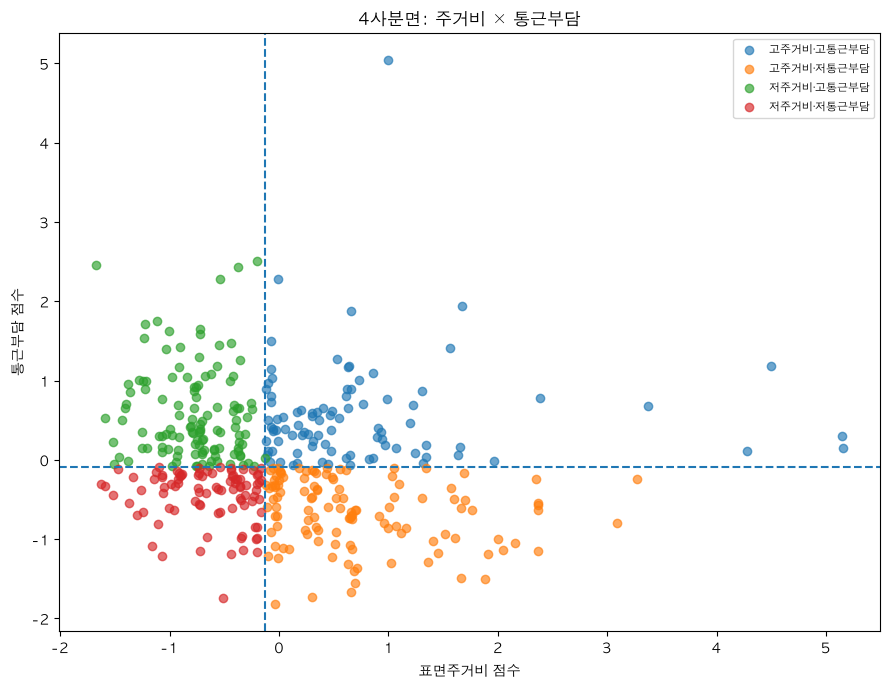

In [13]:
# =========================================================
# 12. 4사분면 유형화 — complete-case 기준
# =========================================================

quadrant = eligible.copy()

burden_q = pd.DataFrame(
    StandardScaler().fit_transform(quadrant[BURDEN_FEATURES]),
    columns=BURDEN_FEATURES,
    index=quadrant.index,
)

structure_q = pd.DataFrame(
    StandardScaler().fit_transform(quadrant[STRUCTURE_FEATURES]),
    columns=STRUCTURE_FEATURES,
    index=quadrant.index,
)

quadrant["주거비점수"] = burden_q["표면주거비_원"]
quadrant["통근부담점수"] = burden_q[
    ["대표_편도통근시간_분", "월통근교통비_원"]
].mean(axis=1)

quadrant["종합부담점수"] = burden_q.mean(axis=1)

quadrant["지역집중통근구조점수"] = (
    structure_q["동일통근권_내부출근비율"]
    - structure_q["목적지_정규화엔트로피"]
) / 2

h_cut = quadrant["주거비점수"].median()
c_cut = quadrant["통근부담점수"].median()
b_cut = quadrant["종합부담점수"].median()
s_cut = quadrant["지역집중통근구조점수"].median()

quadrant["4사분면_주거통근"] = np.select(
    [
        (quadrant["주거비점수"] <= h_cut) & (quadrant["통근부담점수"] <= c_cut),
        (quadrant["주거비점수"] <= h_cut) & (quadrant["통근부담점수"] > c_cut),
        (quadrant["주거비점수"] > h_cut) & (quadrant["통근부담점수"] <= c_cut),
        (quadrant["주거비점수"] > h_cut) & (quadrant["통근부담점수"] > c_cut),
    ],
    [
        "저주거비·저통근부담",
        "저주거비·고통근부담",
        "고주거비·저통근부담",
        "고주거비·고통근부담",
    ],
)

quadrant["4사분면_부담구조"] = np.select(
    [
        (quadrant["종합부담점수"] <= b_cut) & (quadrant["지역집중통근구조점수"] <= s_cut),
        (quadrant["종합부담점수"] <= b_cut) & (quadrant["지역집중통근구조점수"] > s_cut),
        (quadrant["종합부담점수"] > b_cut) & (quadrant["지역집중통근구조점수"] <= s_cut),
        (quadrant["종합부담점수"] > b_cut) & (quadrant["지역집중통근구조점수"] > s_cut),
    ],
    [
        "저부담·광역분산",
        "저부담·지역집중",
        "고부담·광역분산",
        "고부담·지역집중",
    ],
)

eligible["4사분면_주거통근"] = quadrant["4사분면_주거통근"].values
eligible["4사분면_부담구조"] = quadrant["4사분면_부담구조"].values

print("[주거비 × 통근부담]")
display(eligible["4사분면_주거통근"].value_counts().to_frame("행정동수"))

print("[종합부담 × 통근구조]")
display(eligible["4사분면_부담구조"].value_counts().to_frame("행정동수"))

fig, ax = plt.subplots(figsize=(9, 7))
for name, g in quadrant.groupby("4사분면_주거통근"):
    ax.scatter(g["주거비점수"], g["통근부담점수"], alpha=0.65, label=name)

ax.axvline(h_cut, linestyle="--")
ax.axhline(c_cut, linestyle="--")
ax.set_xlabel("표면주거비 점수")
ax.set_ylabel("통근부담 점수")
ax.set_title("4사분면: 주거비 × 통근부담")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 13. 유형 대표동과 경계동

기존 14_2에서 서비스 활용을 위해 만들었던 대표동·경계동을 유지한다.

- **대표동**: 각 유형의 군집 중심에 가장 가까운 5개 행정동
- **경계동**: 자기 군집 중심과 두 번째 군집 중심까지의 거리 차이가 작은 상위 15%

Fuzzy C-Means의 최대 소속확률도 보조정보로 남기지만,
기존 최종본과 동일하게 서비스용 `군집경계_모호` 판정은 **중심거리 차이 기준**으로 계산한다.

In [14]:
# =========================================================
# 13. 대표동 / 경계동
# =========================================================

# Fuzzy hard assignment 결과(labels0)와 실제 군집 중심(centers)을 사용
# centers는 cmeans가 X 공간에서 계산한 중심
dist_to_centers = cdist(X, centers)

nearest_order = np.argsort(dist_to_centers, axis=1)
nearest_dist = np.take_along_axis(
    dist_to_centers,
    nearest_order,
    axis=1,
)

eligible["자기군집중심거리"] = nearest_dist[:, 0]
eligible["두번째군집중심거리"] = nearest_dist[:, 1]
eligible["경계거리차이"] = (
    eligible["두번째군집중심거리"]
    - eligible["자기군집중심거리"]
)

boundary_threshold = eligible["경계거리차이"].quantile(0.15)
eligible["군집경계_모호"] = (
    eligible["경계거리차이"] <= boundary_threshold
)

eligible["퍼지_낮은소속확률"] = (
    eligible["최대소속확률"] < 0.60
)

eligible["군집내_중심거리백분위"] = (
    eligible.groupby("군집_원번호")["자기군집중심거리"]
    .rank(pct=True, ascending=True)
)

REP_PROFILE_FEATURES = [
    c for c in (
        CLUSTER_FEATURES
        + ["목적지_HHI", "청년1인세대_비율"]
    )
    if c in eligible.columns
]

representative_dong = (
    eligible.sort_values(
        ["군집_원번호", "자기군집중심거리"]
    )
    .groupby("군집_원번호")
    .head(5)
    [
        [
            "군집_원번호",
            "행정동_유형",
            "시군구명",
            "행정동명",
            "자기군집중심거리",
            *REP_PROFILE_FEATURES,
        ]
    ]
    .rename(columns={"군집_원번호": "군집"})
)

boundary_dong = (
    eligible[
        eligible["군집경계_모호"]
    ]
    .sort_values("경계거리차이")
    [
        [
            "군집_원번호",
            "행정동_유형",
            "시군구명",
            "행정동명",
            "자기군집중심거리",
            "두번째군집중심거리",
            "경계거리차이",
            "최대소속확률",
            *REP_PROFILE_FEATURES,
        ]
    ]
    .rename(columns={"군집_원번호": "군집"})
)

print("경계동 수:", len(boundary_dong))
display(representative_dong)
display(boundary_dong.head(30))

경계동 수: 63


,군집,행정동_유형,시군구명,행정동명,자기군집중심거리,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
397,1,고비용 통근부담형,송파구,잠실2동,0.2775,"681,666.6667",29.7990,"70,768.0629",0.6211,0.7674,0.0222,3.4300
342,1,고비용 통근부담형,서초구,잠원동,0.3244,"785,000.0000",28.8249,"70,243.0988",0.5908,0.7387,0.0265,12.4100
241,1,고비용 통근부담형,강서구,등촌제3동,0.3284,"767,000.0000",28.8714,"74,083.7074",0.6591,0.7302,0.0286,11.2900
217,1,고비용 통근부담형,마포구,성산제1동,0.3618,"661,666.6667",30.8342,"70,638.1659",0.6201,0.7721,0.0215,25.7100
362,1,고비용 통근부담형,강남구,대치2동,0.4023,"835,000.0000",28.2749,"68,952.9892",0.6906,0.7397,0.0299,7.5000
50,2,광역분산 통근형,성동구,마장동,0.1246,"632,916.6667",28.0704,"66,044.3605",0.3817,0.7846,0.0213,26.5400
75,2,광역분산 통근형,광진구,자양제3동,0.1447,"658,333.3333",29.4161,"65,600.5232",0.3562,0.7917,0.0160,11.3100
66,2,광역분산 통근형,광진구,군자동,0.1606,"650,416.6667",29.2009,"64,922.4169",0.3718,0.8074,0.0145,38.1000
83,2,광역분산 통근형,동대문구,전농제1동,0.1985,"657,500.0000",30.1491,"65,034.6559",0.3685,0.8057,0.0166,19.3700
84,2,광역분산 통근형,동대문구,전농제2동,0.2335,"651,666.6667",26.8751,"66,433.2798",0.4252,0.8028,0.0161,6.3000


,군집,행정동_유형,시군구명,행정동명,자기군집중심거리,두번째군집중심거리,경계거리차이,최대소속확률,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
60,4,근접통근 균형형,성동구,성수1가제2동,0.7325,0.7326,0.0000,0.4181,"810,000.0000",24.8463,"63,905.2143",0.4206,0.7550,0.0285,23.4300
394,1,고비용 통근부담형,송파구,장지동,0.6592,0.6606,0.0014,0.4302,"689,166.6667",31.8499,"67,773.1024",0.7902,0.7494,0.0268,10.5600
262,4,근접통근 균형형,구로구,구로제4동,0.5290,0.5307,0.0017,0.4450,"551,666.6667",29.5132,"63,129.3296",0.5861,0.7477,0.0300,18.1800
300,4,근접통근 균형형,영등포구,대림제2동,0.6117,0.6143,0.0026,0.3376,"526,250.0000",28.2183,"66,378.6415",0.5230,0.7592,0.0258,25.5100
95,2,광역분산 통근형,중랑구,면목제2동,0.4244,0.4270,0.0026,0.4748,"638,333.3333",31.3156,"65,376.1613",0.4631,0.8145,0.0141,12.6700
261,6,고주거비·직주근접형,구로구,구로제3동,0.8812,0.8842,0.0030,0.3094,"649,333.3333",25.6083,"69,872.0634",0.6009,0.6739,0.0751,37.2000
61,4,근접통근 균형형,성동구,성수2가제1동,0.6946,0.6998,0.0052,0.4310,"607,833.3333",24.7229,"62,848.6986",0.4264,0.7428,0.0295,17.6100
403,1,고비용 통근부담형,강동구,상일제2동,0.8394,0.8450,0.0056,0.4107,"646,666.6667",37.7900,"72,501.1234",0.7168,0.7712,0.0271,14.5200
256,5,저주거비·지역연계형,강서구,방화제2동,0.7555,0.7611,0.0056,0.3697,"543,500.0000",30.2699,"69,290.9089",0.6969,0.7099,0.0321,20.6200
42,2,광역분산 통근형,용산구,이촌제2동,0.5437,0.5512,0.0075,0.3088,"613,333.3333",28.7216,"64,742.0077",0.5233,0.7835,0.0245,9.5700


## 12. PCA 시각화

시각화는 군집 구조를 확인하기 위한 보조자료이며, 군집 생성에는 PCA를 사용하지 않는다.

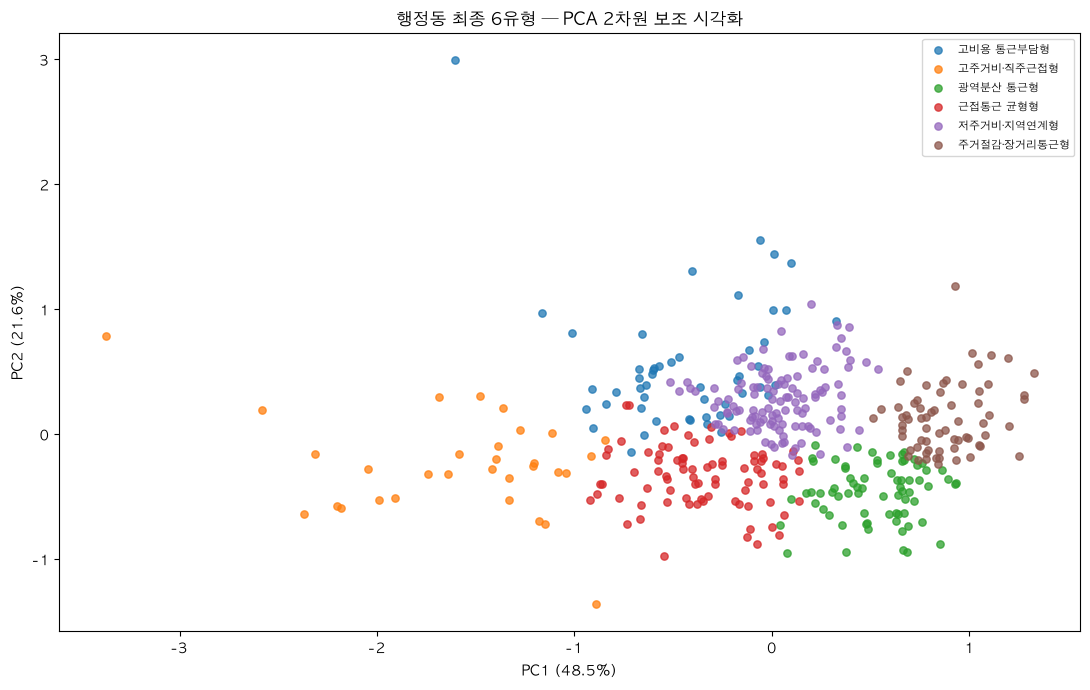

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)

plot_df = eligible[["행정동명", "행정동_유형"]].copy()
plot_df["PC1"] = coords[:, 0]
plot_df["PC2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
for type_name, g in plot_df.groupby("행정동_유형"):
    ax.scatter(g["PC1"], g["PC2"], s=28, alpha=0.75, label=type_name)

ax.set_title("행정동 최종 6유형 — PCA 2차원 보조 시각화")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 13. 427개 전체 결과 복원

유형화 가능 동만 군집 결과를 붙이고, 결측동은 그대로 남긴다.

서비스에서는 `유형화_데이터부족=True`인 지역을
**데이터 부족 지역**으로 별도 표시하면 된다.

In [16]:
final = analysis.copy()

assign_cols = [
    "원본행인덱스",
    "군집_원번호",
    "행정동_유형",
    "최대소속확률",
    "군집경계_모호",
]
assign = eligible[assign_cols].copy()

for col in ["군집_원번호", "행정동_유형", "최대소속확률", "군집경계_모호"]:
    final[col] = pd.NA

for _, row in assign.iterrows():
    idx = int(row["원본행인덱스"])
    for col in ["군집_원번호", "행정동_유형", "최대소속확률", "군집경계_모호"]:
        final.at[idx, col] = row[col]

final["군집"] = final["군집_원번호"]
final["유형화_상태"] = np.where(
    final["유형화_데이터부족"],
    "데이터 부족",
    "유형화 완료",
)

assert len(final) == EXPECTED_DONG_COUNT
assert final["행정동코드"].nunique() == EXPECTED_DONG_COUNT

print(final["유형화_상태"].value_counts(dropna=False))
display(
    final.loc[
        final["유형화_데이터부족"],
        ["행정동코드", "시군구명", "행정동명", "유형화_결측목록", "유형화_상태"]
    ]
)

유형화_상태
유형화 완료    420
데이터 부족      7
Name: count, dtype: int64


,행정동코드,시군구명,행정동명,유형화_결측목록,유형화_상태
164,1135061200,노원구,하계2동,표면주거비_원,데이터 부족
174,1135070000,노원구,상계8동,표면주거비_원,데이터 부족
175,1135071000,노원구,상계9동,표면주거비_원,데이터 부족
346,1165055000,서초구,반포본동,표면주거비_원,데이터 부족
348,1165057000,서초구,반포2동,표면주거비_원,데이터 부족
389,1171056600,송파구,오륜동,표면주거비_원,데이터 부족
407,1171072000,송파구,잠실7동,표면주거비_원,데이터 부족


## 14. 최종 저장

In [17]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_RESULT = PROCESSED_DIR / "dong_typology_final.csv"
OUTPUT_PROFILE = PROCESSED_DIR / "dong_typology_final_cluster_profile.csv"
OUTPUT_INPUT = PROCESSED_DIR / "dong_typology_final_input_14_3.csv"
OUTPUT_YOUTH = PROCESSED_DIR / "dong_typology_youth_posthoc_profile.csv"
OUTPUT_MAPPING = PROCESSED_DIR / "dong_typology_cluster_type_mapping.csv"

RESULT_COLUMNS = [
    "행정동코드", "시군구명", "행정동명",
] + (["권역"] if "권역" in final.columns else []) + [
    "군집",
    "행정동_유형",
    "유형화_상태",
    "유형화_데이터부족",
    "유형화_결측수",
    "유형화_결측목록",
    "표면주거비_결측",
    "표면주거비_원",
    "표면주거비_거래수",
    "표면주거비_집계방식",
    "대표_편도통근시간_분",
    "월통근교통비_원",
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
    "목적지_HHI",
    "청년1인세대_비율",
    "최대소속확률",
    "군집경계_모호",
]

RESULT_COLUMNS = [c for c in RESULT_COLUMNS if c in final.columns]

final[RESULT_COLUMNS].to_csv(OUTPUT_RESULT, index=False, encoding="utf-8-sig")
profile.to_csv(OUTPUT_PROFILE, index=False, encoding="utf-8-sig")
analysis.to_csv(OUTPUT_INPUT, index=False, encoding="utf-8-sig")
mapping_table.to_csv(OUTPUT_MAPPING, index=False, encoding="utf-8-sig")
if len(youth_profile):
    youth_profile.to_csv(OUTPUT_YOUTH, index=False, encoding="utf-8-sig")

print("[저장 완료]")
for p in [OUTPUT_RESULT, OUTPUT_PROFILE, OUTPUT_INPUT, OUTPUT_MAPPING]:
    print("-", p)
if len(youth_profile):
    print("-", OUTPUT_YOUTH)

[저장 완료]
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_final.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_final_cluster_profile.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_final_input_14_3.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_cluster_type_mapping.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_youth_posthoc_profile.csv


## 최종 결론

최종 서비스용 유형화 구조는 기존 14_2와 동일하게 유지한다.

**1단계 — 4사분면**  
현재 거주지의 부담구조를 빠르게 설명한다.

**2단계 — 6개 세부유형**  
현재와 다른 성격의 행정동을 탐색한다.

**3단계 — 15번 실제 근무지 기준 상세비교**  
실제 통근시간·교통비·시간비용을 다시 계산한다.

이번 14_3에서 달라진 것은 다음뿐이다.

- 표면주거비: 거래단위 pooled 중앙값
- 표면주거비 결측: 임의 대체하지 않음
- 생활소비부담지수: 최종 유형화에서 제외
- 청년 1인세대 비율: 사후해석 전용

결측동은 427개 전체 결과에는 유지되지만, 근거 없는 유형이나 4사분면 값을 만들지 않는다.

In [18]:
# =========================================================
# 추가 검증. 표면주거비 수정 후 최적 군집 수 k 재검토
# =========================================================

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

K_RANGE = range(2, 11)
M_VALUE = 1.5

k_results = []
k_memberships = {}
k_labels = {}
k_centers = {}

for k in K_RANGE:

    centers_k, membership_k, _, _, _, _, fpc_k = fuzz.cluster.cmeans(
        X.T,
        c=k,
        m=M_VALUE,
        error=0.005,
        maxiter=1000,
        init=None,
        seed=RANDOM_STATE,
    )

    labels_k = np.argmax(
        membership_k,
        axis=0,
    )

    max_membership_k = np.max(
        membership_k,
        axis=0,
    )

    # 군집별 개수
    cluster_sizes = pd.Series(
        labels_k
    ).value_counts().sort_index()

    min_cluster_size = cluster_sizes.min()
    max_cluster_size = cluster_sizes.max()

    k_results.append({
        "k": k,

        # 군집 분리도
        "silhouette":
            silhouette_score(
                X,
                labels_k,
            ),

        "calinski_harabasz":
            calinski_harabasz_score(
                X,
                labels_k,
            ),

        "davies_bouldin":
            davies_bouldin_score(
                X,
                labels_k,
            ),

        # Fuzzy 자체 지표
        "fpc":
            float(fpc_k),

        "평균_최대소속확률":
            float(
                max_membership_k.mean()
            ),

        "최대소속확률_중앙값":
            float(
                np.median(
                    max_membership_k
                )
            ),

        "소속확률_0.6미만_비율":
            float(
                (
                    max_membership_k < 0.60
                ).mean()
            ),

        # 군집 크기 점검
        "최소군집크기":
            int(min_cluster_size),

        "최대군집크기":
            int(max_cluster_size),

        "최소군집비율":
            float(
                min_cluster_size
                / len(labels_k)
            ),
    })

    k_memberships[k] = membership_k
    k_labels[k] = labels_k
    k_centers[k] = centers_k


k_evaluation = pd.DataFrame(
    k_results
)

display(
    k_evaluation.round(4)
)

,k,silhouette,calinski_harabasz,davies_bouldin,fpc,평균_최대소속확률,최대소속확률_중앙값,소속확률_0.6미만_비율,최소군집크기,최대군집크기,최소군집비율
0,2,0.2495,159.8668,1.4362,0.7643,0.8304,0.8864,0.1286,202,218,0.4810
1,3,0.2574,156.0595,1.3811,0.7238,0.8078,0.8634,0.1667,81,194,0.1929
2,4,0.2318,138.5603,1.4338,0.6627,0.7618,0.8092,0.2357,41,131,0.0976
3,5,0.2315,127.9363,1.3506,0.6213,0.7331,0.7705,0.2786,34,124,0.0810
4,6,0.2196,123.0058,1.3184,0.6003,0.7184,0.7366,0.3024,31,115,0.0738
5,7,0.1884,112.9019,1.3858,0.5665,0.6924,0.7269,0.3405,27,79,0.0643
6,8,0.1784,104.6117,1.3393,0.5414,0.6712,0.6979,0.3762,22,74,0.0524
7,9,0.1822,101.4046,1.3830,0.5369,0.6666,0.6871,0.3929,11,76,0.0262
8,10,0.1736,94.4648,1.4316,0.5204,0.6508,0.6697,0.4167,11,69,0.0262


In [19]:
# =========================================================
# 지표별 상대 비교용 표
# 주의: 이 점수 자체를 최종 k 결정 기준으로 쓰는 게 아니라
# 여러 지표를 한눈에 보기 위한 보조자료
# =========================================================

eval_rank = k_evaluation.copy()

# 높을수록 좋은 지표
higher_better = [
    "silhouette",
    "calinski_harabasz",
    "fpc",
    "평균_최대소속확률",
    "최대소속확률_중앙값",
]

# 낮을수록 좋은 지표
lower_better = [
    "davies_bouldin",
    "소속확률_0.6미만_비율",
]

for col in higher_better:
    eval_rank[f"{col}_순위"] = (
        eval_rank[col]
        .rank(
            ascending=False,
            method="min",
        )
    )

for col in lower_better:
    eval_rank[f"{col}_순위"] = (
        eval_rank[col]
        .rank(
            ascending=True,
            method="min",
        )
    )

rank_cols = [
    c
    for c in eval_rank.columns
    if c.endswith("_순위")
]

eval_rank["평균순위"] = (
    eval_rank[rank_cols]
    .mean(axis=1)
)

display(
    eval_rank[
        [
            "k",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "fpc",
            "평균_최대소속확률",
            "소속확률_0.6미만_비율",
            "최소군집크기",
            "최소군집비율",
            "평균순위",
        ]
    ]
    .sort_values("평균순위")
    .round(4)
)

,k,silhouette,calinski_harabasz,davies_bouldin,fpc,평균_최대소속확률,소속확률_0.6미만_비율,최소군집크기,최소군집비율,평균순위
1,3,0.2574,156.0595,1.3811,0.7238,0.8078,0.1667,81,0.1929,2.1429
0,2,0.2495,159.8668,1.4362,0.7643,0.8304,0.1286,202,0.4810,2.2857
2,4,0.2318,138.5603,1.4338,0.6627,0.7618,0.2357,41,0.0976,3.7143
3,5,0.2315,127.9363,1.3506,0.6213,0.7331,0.2786,34,0.0810,3.8571
4,6,0.2196,123.0058,1.3184,0.6003,0.7184,0.3024,31,0.0738,4.4286
5,7,0.1884,112.9019,1.3858,0.5665,0.6924,0.3405,27,0.0643,6.0000
6,8,0.1784,104.6117,1.3393,0.5414,0.6712,0.3762,22,0.0524,6.4286
7,9,0.1822,101.4046,1.3830,0.5369,0.6666,0.3929,11,0.0262,7.4286
8,10,0.1736,94.4648,1.4316,0.5204,0.6508,0.4167,11,0.0262,8.7143


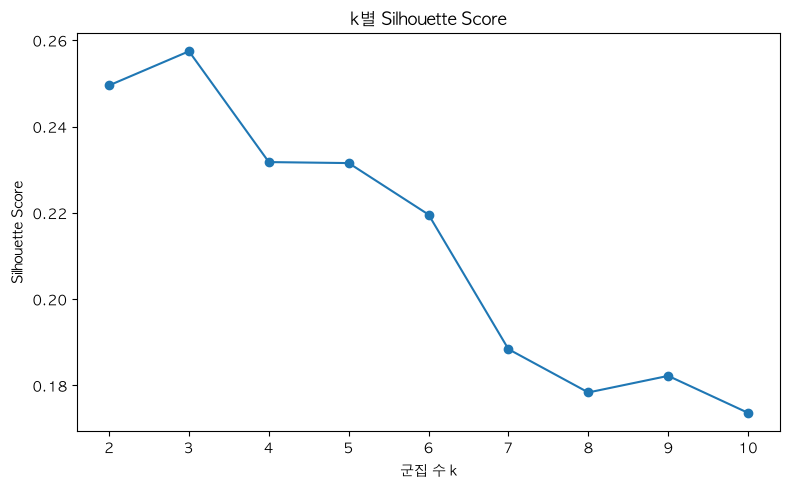

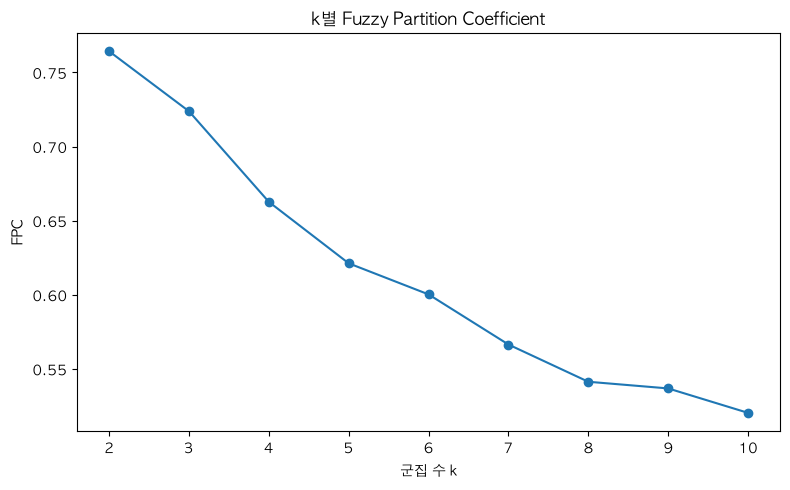

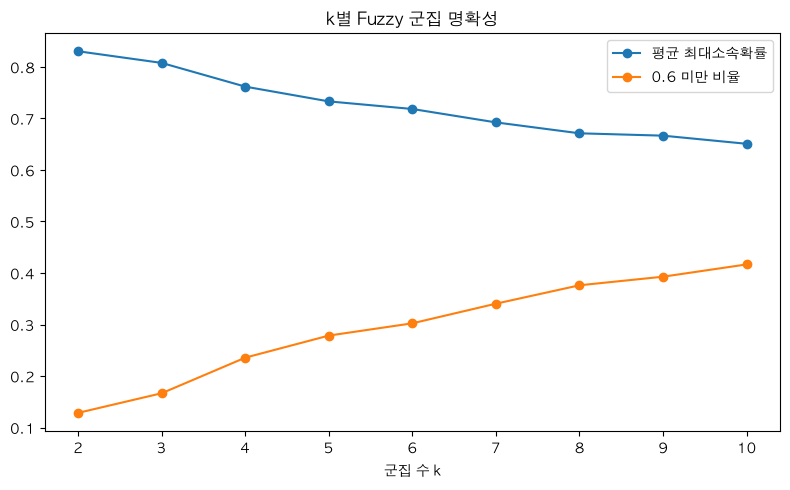

In [20]:
# =========================================================
# k별 평가 지표 시각화
# =========================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_evaluation["k"],
    k_evaluation["silhouette"],
    marker="o",
)

ax.set_xticks(
    k_evaluation["k"]
)

ax.set_xlabel("군집 수 k")
ax.set_ylabel("Silhouette Score")
ax.set_title(
    "k별 Silhouette Score"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_evaluation["k"],
    k_evaluation["fpc"],
    marker="o",
)

ax.set_xticks(
    k_evaluation["k"]
)

ax.set_xlabel("군집 수 k")
ax.set_ylabel("FPC")
ax.set_title(
    "k별 Fuzzy Partition Coefficient"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_evaluation["k"],
    k_evaluation["평균_최대소속확률"],
    marker="o",
    label="평균 최대소속확률",
)

ax.plot(
    k_evaluation["k"],
    k_evaluation["소속확률_0.6미만_비율"],
    marker="o",
    label="0.6 미만 비율",
)

ax.set_xticks(
    k_evaluation["k"]
)

ax.set_xlabel("군집 수 k")
ax.set_title(
    "k별 Fuzzy 군집 명확성"
)

ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# k별 군집 크기 확인
# =========================================================

cluster_size_rows = []

for k in K_RANGE:

    labels_k = k_labels[k]

    counts = (
        pd.Series(labels_k + 1)
        .value_counts()
        .sort_index()
    )

    for cluster_no, n in counts.items():

        cluster_size_rows.append({
            "k": k,
            "군집": cluster_no,
            "행정동수": n,
            "비율": n / len(labels_k),
        })

cluster_size_table = pd.DataFrame(
    cluster_size_rows
)

display(
    cluster_size_table
    .pivot(
        index="k",
        columns="군집",
        values="행정동수",
    )
    .fillna("-")
)

군집,1,2,3,4,5,6,7,8,9,10
k,,,,,,,,,,
2,202.0000,218.0000,-,-,-,-,-,-,-,-
3,81.0000,145.0000,194.0000,-,-,-,-,-,-,-
4,41.0000,131.0000,130.0000,118.0000,-,-,-,-,-,-
5,59.0000,124.0000,110.0000,93.0000,34.0000,-,-,-,-,-
6,51.0000,72.0000,66.0000,85.0000,115.0000,31.0000,-,-,-,-
7,27.0000,69.0000,67.0000,47.0000,72.0000,59.0000,79.0000,-,-,-
8,42.0000,60.0000,68.0000,74.0000,53.0000,53.0000,48.0000,22.0000,-,-
9,29.0000,60.0000,50.0000,76.0000,34.0000,49.0000,43.0000,11.0000,68.0000,-
10,27.0000,46.0000,55.0000,48.0000,36.0000,46.0000,69.0000,11.0000,34.0000,48.0000


In [22]:
# =========================================================
# k=3~6 실제 군집 프로파일 비교
# =========================================================

COMPARE_K = [3, 4, 5, 6]

profile_tables = {}

# 원래 5개 변수 기준 표준화
profile_scaler = StandardScaler()

profile_z = pd.DataFrame(
    profile_scaler.fit_transform(
        eligible[CLUSTER_FEATURES]
    ),
    columns=CLUSTER_FEATURES,
    index=eligible.index,
)

for k in COMPARE_K:

    labels_k = k_labels[k]

    temp = profile_z.copy()
    temp["군집"] = labels_k + 1

    profile_k = (
        temp
        .groupby("군집")[CLUSTER_FEATURES]
        .mean()
        .round(2)
    )

    size_k = (
        pd.Series(labels_k + 1)
        .value_counts()
        .sort_index()
        .rename("행정동수")
    )

    profile_k.insert(
        0,
        "행정동수",
        size_k,
    )

    profile_tables[k] = profile_k

    print("=" * 80)
    print(f"k = {k}")
    print("=" * 80)

    display(profile_k)

k = 3


,행정동수,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피
군집,,,,,,
1,81,1.1700,-1.0900,0.0500,0.7000,-1.4700
2,145,-0.3700,0.4000,-0.1200,-1.1300,0.7500
3,194,-0.2100,0.1600,0.0700,0.5500,0.0500


k = 4


,행정동수,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피
군집,,,,,,
1,41,1.4100,-1.4100,0.4000,1.0600,-2.1800
2,131,-0.4100,0.5100,-0.0700,-1.1700,0.8200
3,130,-0.3500,0.5100,0.3100,0.7100,0.1500
4,118,0.3500,-0.6400,-0.4100,0.1500,-0.3200


k = 5


,행정동수,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피
군집,,,,,,
1,59,0.7900,0.0700,1.2000,0.7600,-0.3400
2,124,-0.3900,0.5400,-0.0500,-1.2100,0.8400
3,110,-0.5200,0.5200,-0.0700,0.6600,0.2400
4,93,0.1300,-0.7800,-0.6300,-0.0200,-0.3200
5,34,1.3900,-1.6600,0.0500,1.0100,-2.3800


k = 6


,행정동수,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피
군집,,,,,,
1,51,0.8300,0.1500,1.4100,0.7700,-0.3200
2,72,-0.1500,-0.2000,-0.3000,-1.3800,0.5300
3,66,-0.6700,1.2200,0.1500,-0.9100,1.0600
4,85,0.2700,-0.8100,-0.6400,0.1500,-0.4600
5,115,-0.4700,0.4300,-0.0900,0.6500,0.2000
6,31,1.4400,-1.7400,0.1500,1.0500,-2.4600


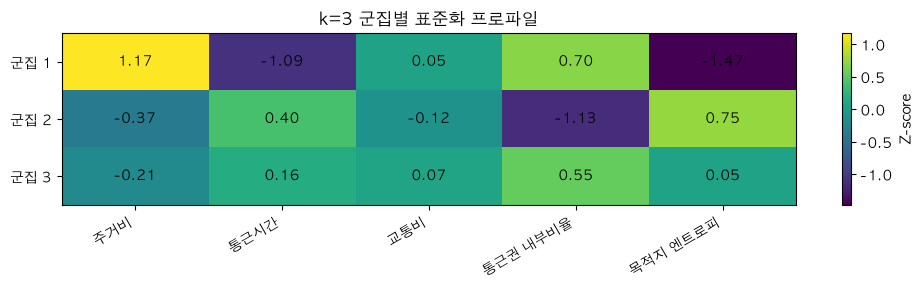

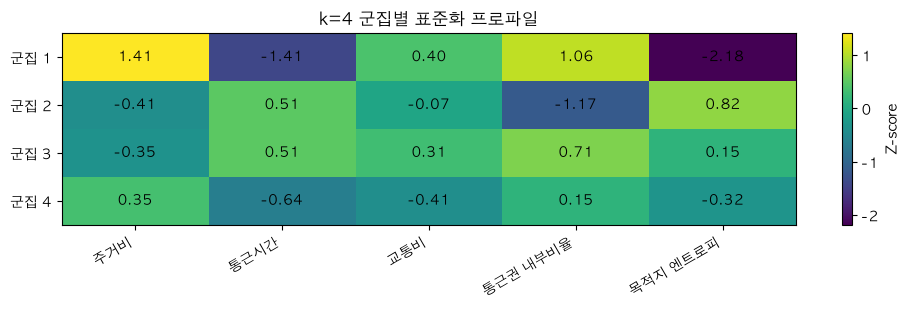

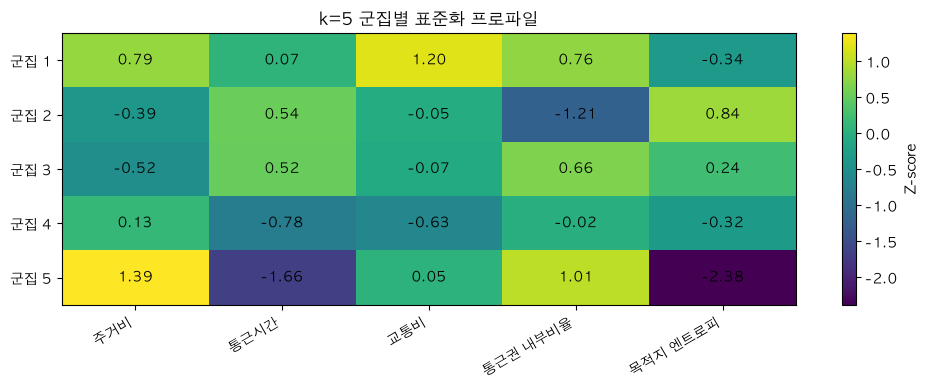

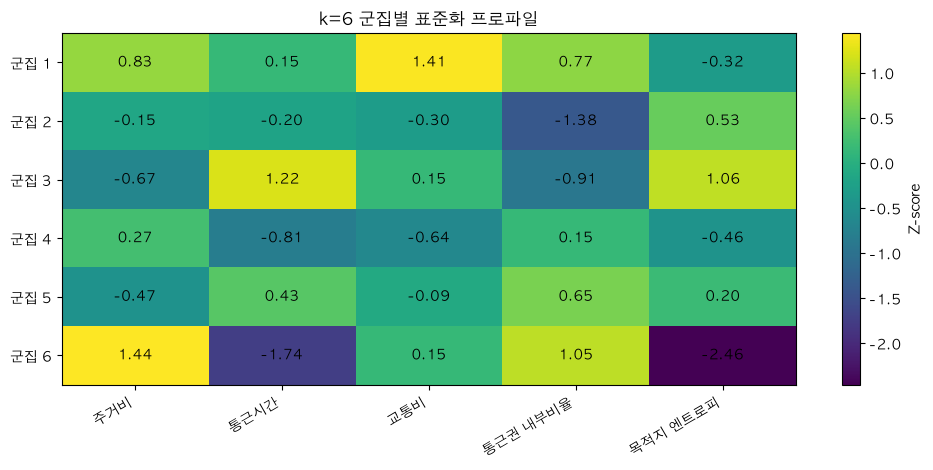

In [23]:
# =========================================================
# k별 프로파일 시각화
# =========================================================

for k in COMPARE_K:

    profile_k = (
        profile_tables[k]
        .drop(columns="행정동수")
    )

    fig, ax = plt.subplots(
        figsize=(10, max(3, k * 0.8))
    )

    im = ax.imshow(
        profile_k.values,
        aspect="auto",
    )

    ax.set_xticks(
        range(len(profile_k.columns))
    )

    ax.set_xticklabels(
        [
            "주거비",
            "통근시간",
            "교통비",
            "통근권 내부비율",
            "목적지 엔트로피",
        ],
        rotation=30,
        ha="right",
    )

    ax.set_yticks(
        range(len(profile_k.index))
    )

    ax.set_yticklabels(
        [
            f"군집 {i}"
            for i in profile_k.index
        ]
    )

    for i in range(profile_k.shape[0]):
        for j in range(profile_k.shape[1]):

            ax.text(
                j,
                i,
                f"{profile_k.iloc[i, j]:.2f}",
                ha="center",
                va="center",
            )

    ax.set_title(
        f"k={k} 군집별 표준화 프로파일"
    )

    plt.colorbar(
        im,
        ax=ax,
        label="Z-score",
    )

    plt.tight_layout()
    plt.show()

## 군집 수 재검토 및 최종 k 선정

표면주거비 산출 방식을 기존의 주택유형별 집계값 결합 방식에서 **거래단위 원자료를 이용한 행정동별 pooled 중앙값**으로 변경했기 때문에, 기존에 선택했던 군집 수 `k=6`이 여전히 적절한지 다시 확인하였다.

이에 동일한 Fuzzy C-Means 조건(`m=1.5`)에서 `k=2~10`을 대상으로 Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, FPC(Fuzzy Partition Coefficient), 최대 소속확률 및 군집 크기를 비교하였다.

### 1. 내부 평가 결과

군집 분리도만 보면 `k=3`이 가장 양호한 결과를 보였다.

- **k=3**
  - Silhouette Score: **0.2574**
  - FPC: **0.7238**
  - 평균 최대소속확률: **0.8078**
  - 최대소속확률 0.6 미만 비율: **16.7%**
  - 최소 군집 크기: **81개 동**

반면 기존에 사용했던 `k=6`은 다음과 같이 나타났다.

- **k=6**
  - Silhouette Score: **0.2196**
  - Davies-Bouldin Index: **1.3184**
  - FPC: **0.6003**
  - 평균 최대소속확률: **0.7184**
  - 최대소속확률 0.6 미만 비율: **30.2%**
  - 최소 군집 크기: **31개 동**

따라서 **통계적 분리도와 소속 명확성만 기준으로 할 경우 k=3이 더 안정적**인 것으로 확인되었다. 또한 k가 증가할수록 FPC와 평균 최대소속확률이 감소하고, 소속이 모호한 행정동의 비율이 증가하는 경향이 나타났다.

### 2. k=3과 k=6의 해석력 비교

그러나 본 분석의 목적은 단순히 가장 강하게 분리되는 군집을 찾는 것뿐만 아니라, **행정동별 주거비와 통근부담 구조의 차이를 서비스에서 해석 가능한 유형으로 구분하는 것**이다.

`k=3`의 경우 통계적으로는 비교적 안정적이었으나 다수의 행정동이 큰 군집으로 통합되어, 주거비 절감과 장거리 통근의 교환관계, 높은 교통비 부담, 지역 내 통근과 광역 통근 구조 등의 차이를 충분히 세분화하기 어려웠다.

반면 `k=6`에서는 기존 분석에서 확인했던 다음의 서로 다른 부담구조가 비교적 명확하게 유지되었다.

- 고비용 통근부담형
- 근접통근 균형형
- 광역분산 통근형
- 주거절감·장거리통근형
- 저주거비·지역연계형
- 고주거비·직주근접형

특히 **주거비는 상대적으로 낮지만 통근시간이 길고 목적지가 분산된 `주거절감·장거리통근형`이 별도의 유형으로 분리**된다는 점은, 주거비만으로는 드러나지 않는 실제 통근부담을 함께 보여주고자 하는 서비스의 분석 목적과 부합한다.

또한 k=6에서 최소 군집의 크기가 31개 행정동으로 나타나, 특정 소수 행정동만을 별도의 군집으로 과도하게 분리한 결과라고 보기는 어렵다.

### 3. 최종 결정

따라서 이번 재검토에서는 **k=6을 통계적으로 가장 우수한 군집 수라고 판단한 것은 아니다.**

내부 평가지표에서는 k=3이 가장 안정적인 결과를 보였으나, k=3은 서비스에서 활용하고자 하는 세부 부담구조를 충분히 구분하지 못하였다. 반면 k=6은 분리도가 일부 낮아지는 대신 주거비·통근시간·교통비·통근구조의 차이를 의미 있는 6개 유형으로 구분할 수 있었으며, 각 군집의 규모 역시 해석 가능한 수준으로 유지되었다.

이에 따라 **내부 평가지표와 서비스 해석력을 함께 고려하여 최종 군집 수는 기존과 동일하게 `k=6`으로 유지한다.**

> **최종 선택:** Fuzzy C-Means, `k=6`, `m=1.5`  
> 단, k=6은 '통계적 최적값'이 아니라 **군집 품질과 서비스 목적에 필요한 해석 세분화 수준을 함께 고려한 최종 선택값**으로 해석한다.